# Visión por computador MIA-B
# Entrega ejercicio práctico clase 1 - Grupo 3

**Fecha:** 2026-03-08  
**Versión:** 1.0

## Descripción
El presente documento tiene por objetivo presentar la tarea corespondencia a la tarea 1

## Autores:
 - Calahorrano Geovanna
 - Vega Ivan
 - Yanez Carlos

## Actividad Parte 1
#### 1.-Cargar una imagen con OpenCV
#### 2.-Mostrar la imagen cargada

### Configuración del Entorno

In [1]:
# Descargar librerias
!pip install opencv-python
!pip install matplotlib

Archivo seleccionado: /Users/charlie/Documents/GitHub/Vision-por-computador-MIA-B---Grupo-3/Clase 1/dataset/imagen1.jpg


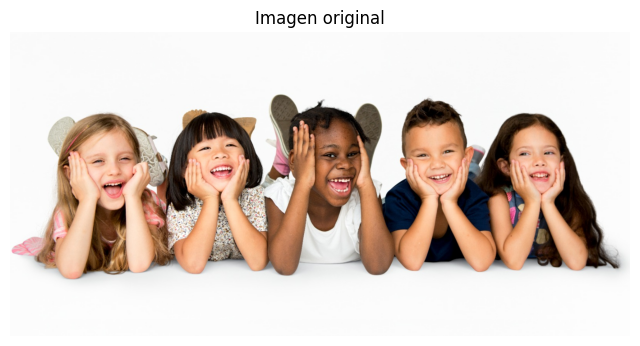

In [2]:
# Importar bibliotecas
import cv2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
#Librerias para obtener el path de un archivo
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()
file_path = askopenfilename(title="Seleccione un archivo")
print("Archivo seleccionado:", file_path)
# DEFINIR RUTA
ruta_archivo = file_path

# Cargar imagen
try:
    img = mpimg.imread(ruta_archivo)

    # Mostrar imagen
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title("Imagen original")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print("Error: no se encontró la imagen. Verifique la ruta.")

#### 3.-Convertirla a Escala de  grisis

In [3]:
# Leer imagen
img = cv2.imread(ruta_archivo)

# Convertir a escala de grises
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#### 4.-Aplicar el filtro de deteccion  de bordes Canny
#### 5.-Mostrar la imagen procesada
#### 6.-Buscar otro filtro diferente a canny
#### 7.-Aplicar el filtro a la imagen original y la  procesada con el filtro canny
#### 8.-Mostrar los resultados  de las 2 imagenes  procesadas con el nuevo filtro

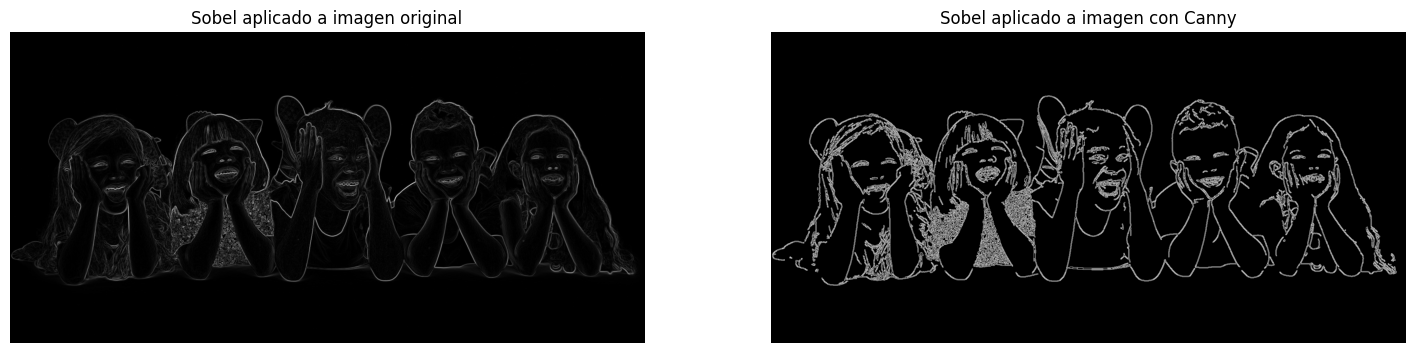

In [4]:
# -------- FILTRO CANNY --------
canny_edges = cv2.Canny(gray_image, 100, 200)

# -------- NUEVO FILTRO: SOBEL --------
# Sobel en X
sobelx = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)

# Sobel en Y
sobely = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)

# Magnitud del gradiente
sobel_original = cv2.magnitude(sobelx, sobely)

# -------- SOBEL aplicado a la imagen con CANNY --------
sobelx_canny = cv2.Sobel(canny_edges, cv2.CV_64F, 1, 0, ksize=3)
sobely_canny = cv2.Sobel(canny_edges, cv2.CV_64F, 0, 1, ksize=3)

sobel_canny = cv2.magnitude(sobelx_canny, sobely_canny)

# -------- MOSTRAR RESULTADOS --------

 # 3. Configurar la visualización


plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.title("Sobel aplicado a imagen original")
plt.imshow(sobel_original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Sobel aplicado a imagen con Canny")
plt.imshow(sobel_canny, cmap='gray')
plt.axis('off')

plt.show()

### Detección de rostros- método 1

In [5]:
# Definir la ruta de la imagen de entrada
imagePath = file_path

In [6]:
# Mostrar la forma (shape) de la imagen
# Esto proporciona información sobre las dimensiones de la imagen
img.shape

(785, 1600, 3)

In [7]:
# Convertir la imagen a escala de grises
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
# Mostrar la forma (shape) de la imagen en escala de grises
gray_image.shape

(785, 1600)

(np.float64(-0.5), np.float64(1599.5), np.float64(784.5), np.float64(-0.5))

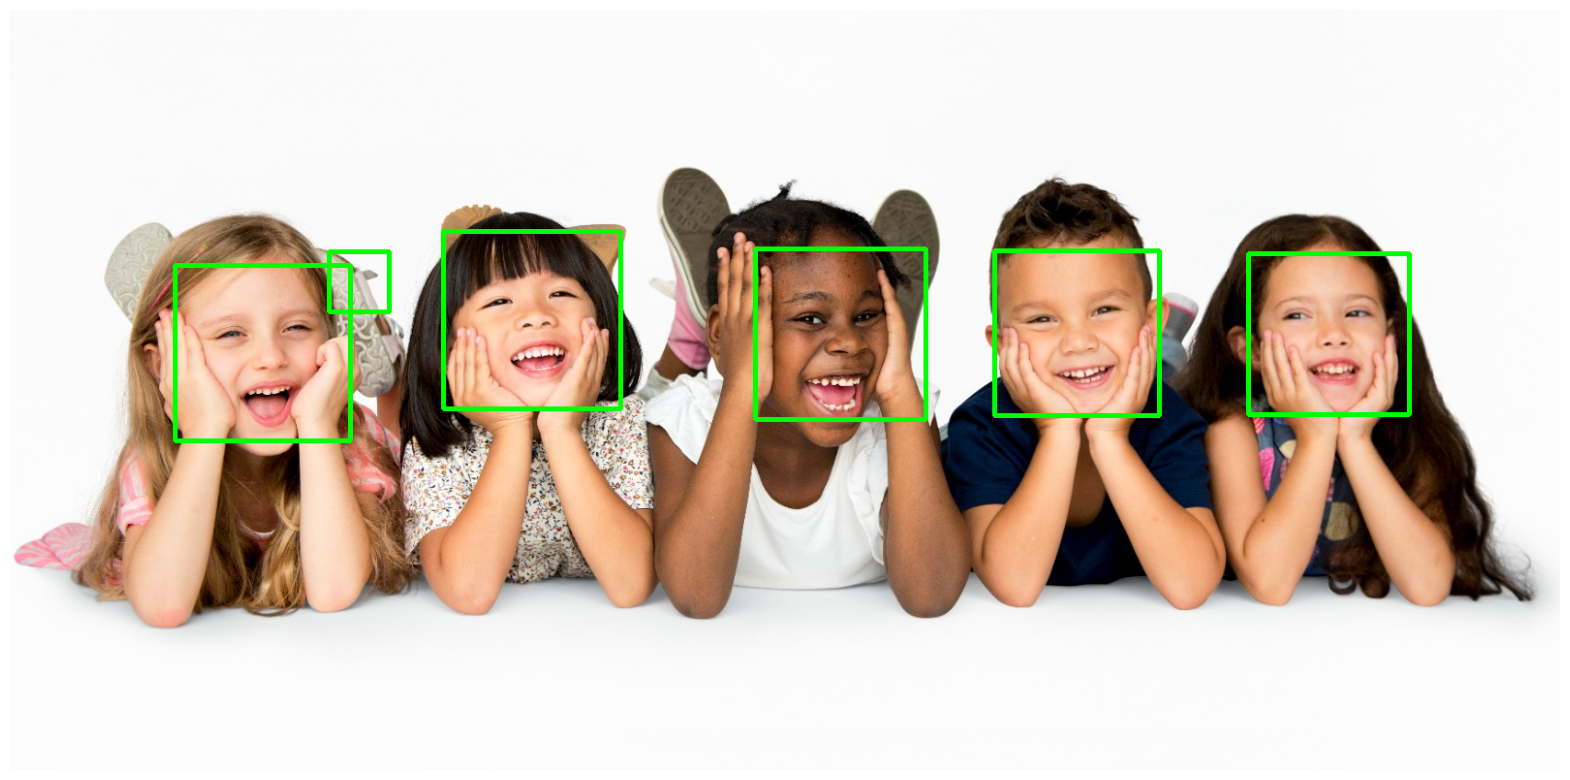

In [8]:
# Cargar un clasificador pre-entrenado para la detección de caras
face_classifier = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
 
# Detectar caras en la imagen en escala de grises
face = face_classifier.detectMultiScale(
    gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
)
 
# Dibujar rectángulos alrededor de las caras detectadas
for (x, y, w, h) in face:
    cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 4)
 
# Convertir la imagen al formato RGB para mostrarla con Matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Crear una figura de Matplotlib para mostrar la imagen
plt.figure(figsize=(20,10)) # Configuramos el tamaño de la figura
plt.imshow(img_rgb) # Mostramos la imagen en la figura
plt.axis('off') # No dibujamos los ejes de la figura

### Detección de rostros- método 2

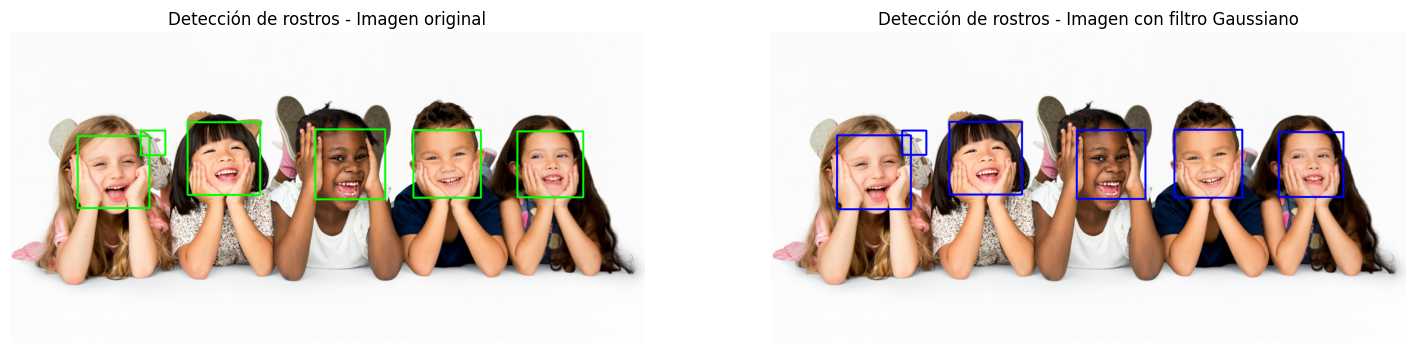

In [9]:
# Leer imagen
img = cv2.imread(imagePath)

# Copias para mostrar resultados
img_original = img.copy()
img_gaussian = img.copy()

# Convertir a escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# -------- NUEVO METODO: FILTRO GAUSSIANO --------
gaussian = cv2.GaussianBlur(gray,(5,5),0)

# Cargar clasificador de rostros
face_classifier = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# -------- DETECCION EN IMAGEN ORIGINAL --------
faces_original = face_classifier.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40,40)
)

for (x,y,w,h) in faces_original:
    cv2.rectangle(img_original,(x,y),(x+w,y+h),(0,255,0),3)

# -------- DETECCION EN IMAGEN CON FILTRO GAUSSIANO --------
faces_gaussian = face_classifier.detectMultiScale(
    gaussian,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40,40)
)

for (x,y,w,h) in faces_gaussian:
    cv2.rectangle(img_gaussian,(x,y),(x+w,y+h),(255,0,0),3)

# Convertir a RGB para matplotlib
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
img_gaussian = cv2.cvtColor(img_gaussian, cv2.COLOR_BGR2RGB)

# -------- MOSTRAR RESULTADOS --------
plt.figure(figsize=(18,8))

plt.subplot(1,2,1)
plt.title("Detección de rostros - Imagen original")
plt.imshow(img_original)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Detección de rostros - Imagen con filtro Gaussiano")
plt.imshow(img_gaussian)
plt.axis("off")

plt.show()

#### 9.-Escribir sobre la diferencia de los resultados de las dos imagenes

1. Aplicación del operador Sobel sobre una imagen previamente procesada con Canny
Cuando aplicamos el operador Sobel a una imagen que ya ha sido procesada con el algoritmo Canny, esencialmente estamos intentando encontrar los gradientes de esos bordes ya optimizados por Canny.
El operador Sobel no introduce información estructural adicional. Más bien, tiende a reforzar los gradientes ya presentes en los contornos detectados por Canny. En algunos casos, esta operación puede incluso generar efectos no deseados, tales como:
• Engrosamiento de los bordes previamente adelgazados por Canny.
• Introducción de artefactos derivados de la amplificación del gradiente.
• Pérdida parcial de la limpieza y precisión logradas por el proceso de supresión de no-máximos.
En consecuencia, el uso de Sobel después de Canny suele tener un valor limitado desde el punto de vista de la detección de bordes, ya que Canny proporciona por sí mismo una representación optimizada y suficientemente robusta de los contornos.
 
 
2. Aplicación del operador Sobel directamente sobre la imagen original
Cuando Sobel se aplica directamente sobre la imagen original, permite identificar regiones donde se producen variaciones abruptas de intensidad, lo que constituye una aproximación efectiva para la detección inicial de bordes. Sin embargo, esta técnica presenta ciertas limitaciones:
• Los bordes resultantes suelen ser más gruesos que los obtenidos mediante métodos más avanzados.
• Es más sensible al ruido, debido a que no incorpora un proceso de suavizado tan robusto como el utilizado en Canny.
• La precisión en la localización de los contornos es menor, especialmente en imágenes con variaciones complejas de iluminación o textura.


#### Conclusión
Aplicar el operador Sobel sobre la imagen original permite obtener una estimación inicial de los bordes basada en el gradiente, aunque con menor precisión y mayor grosor en los contornos. Por otro lado, aplicar Sobel después del algoritmo Canny no suele aportar información adicional relevante, ya que Canny produce bordes más delgados, limpios y robustos. En la práctica, Canny es preferido cuando se requiere una detección de bordes de alta calidad, mientras que Sobel se utiliza principalmente como herramienta de análisis de gradientes o como etapa preliminar en procesos más complejos.

## Actividad Parte 2:
#### 1.-Encontrar/ Crear una base de datos de imágenes (2 clases, mínimo 20 imágenes por clase).
#### 2.-Importar la base de datos y visualizar 5 ejemplos por cada clase.
#### 3.-Opcional (dividir la base de datos en entrenamiento y prueba).
#### 4.-Extraemos  características de las imágenes.
#### 5.-Creamos un clasificador de imágenes en base a las características extraídas.
#### 6.-Evaluamos el clasificador (al menos exactitud 70%)

Clases seleccionadas: ['Ariel Sharon' 'Colin Powell']
Total de imágenes: 313


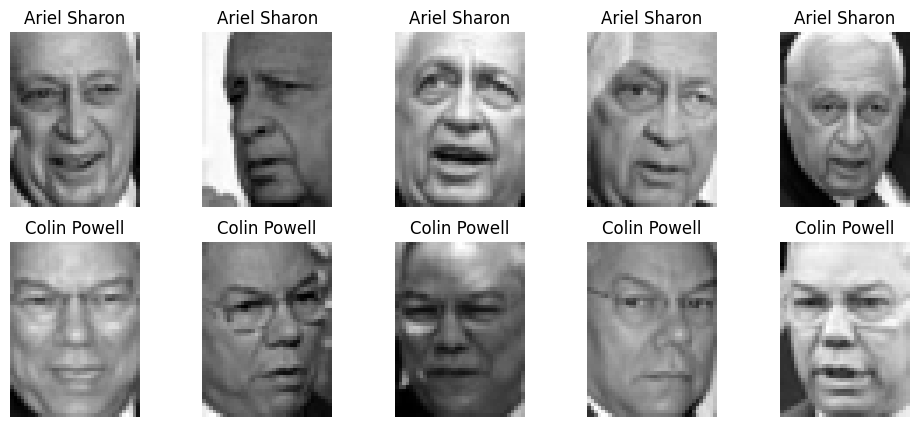


--- Resultados ---
Exactitud (Accuracy): 93.62%

Reporte de Clasificación:
              precision    recall  f1-score   support

Ariel Sharon       0.91      0.83      0.87        24
Colin Powell       0.94      0.97      0.96        70

    accuracy                           0.94        94
   macro avg       0.93      0.90      0.91        94
weighted avg       0.94      0.94      0.94        94



In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
from skimage import exposure

# --- 1. CARGAR BASE DE DATOS (2 clases, min 20 fotos) ---
# Filtramos para obtener personajes con al menos 50 imágenes para asegurar calidad
data = fetch_lfw_people(min_faces_per_person=50, resize=0.4)
# Tomamos solo las primeras 2 clases (nombres)
class_names = data.target_names[:2]
mask = np.isin(data.target, [0, 1])

X = data.images[mask]
y = data.target[mask]

print(f"Clases seleccionadas: {class_names}")
print(f"Total de imágenes: {len(X)}")

# --- 2. VISUALIZAR 5 EJEMPLOS POR CLASE ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(2):
    idx = np.where(y == i)[0][:5]
    for j, img_idx in enumerate(idx):
        axes[i, j].imshow(X[img_idx], cmap='gray')
        axes[i, j].set_title(class_names[i])
        axes[i, j].axis('off')
plt.show()

# --- 3. DIVIDIR EN ENTRENAMIENTO Y PRUEBA ---
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 4. EXTRACCIÓN DE CARACTERÍSTICAS (HOG) ---
def extract_hog_features(img_array):
    features_list = []
    for img in img_array:
        # Extraemos el histograma de gradientes orientados
        fd = hog(img, orientations=8, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), visualize=False)
        features_list.append(fd)
    return np.array(features_list)

X_train = extract_hog_features(X_train_raw)
X_test = extract_hog_features(X_test_raw)

# --- 5. CREAR Y ENTRENAR EL CLASIFICADOR (SVM) ---
clf = SVC(kernel='linear', probability=True, random_state=42)
clf.fit(X_train, y_train)

# --- 6. EVALUACIÓN ---
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Resultados ---")
print(f"Exactitud (Accuracy): {accuracy * 100:.2f}%")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=class_names))

## Adicional: Descargar de un set de datos de forma manual

## 1. Descarga dataset (20 real images)

In [ ]:
import os
import cv2
import zipfile
from tqdm import tqdm

# Define the image directory
img_dir = "BSR/BSDS500/data/images/train"  # Update this path as needed
if not os.path.exists(img_dir):
    raise FileNotFoundError(f"Image directory '{img_dir}' not found.")

# List of selected images
selected = [
    "3096.jpg", "65019.jpg", "86016.jpg", "118035.jpg", "124084.jpg",
    "134052.jpg", "14037.jpg", "156079.jpg", "175083.jpg", "181018.jpg",
    "208001.jpg", "223061.jpg", "241004.jpg", "271008.jpg", "302003.jpg",
    "326025.jpg", "35010.jpg", "42049.jpg", "48017.jpg", "65033.jpg"
]

# Define the output directory
output_dir = "bsds20_128/images"
os.makedirs(output_dir, exist_ok=True)

print("Processing images...")

# Process and resize images
for img_name in tqdm(selected):
    path = os.path.join(img_dir, img_name)
    
    if os.path.exists(path):
        img = cv2.imread(path)
        if img is None:
            print(f"Warning: Unable to read image '{img_name}'. Skipping.")
            continue
        img = cv2.resize(img, (128, 128))
        cv2.imwrite(os.path.join(output_dir, img_name), img)
    else:
        print(f"Warning: Image '{img_name}' not found. Skipping.")

# Create a ZIP file of the processed images
zip_name = "dataset_bsds20_128.zip"
with zipfile.ZipFile(zip_name, "w") as z:
    for file in os.listdir(output_dir):
        z.write(os.path.join(output_dir, file), file)

print("ZIP created:", zip_name)

## 2. Cargar el set de datos y visualizar

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

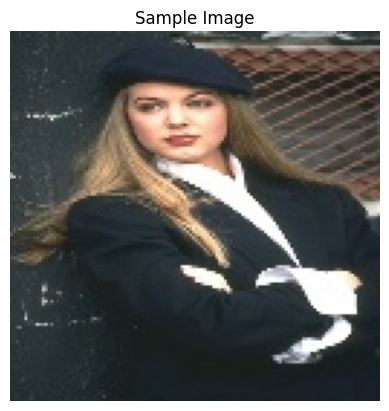

In [11]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/Users/charlie/Documents/GitHub/Vision-por-computador-MIA-B---Grupo-3/Clase 1/dataset/train/181018.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title('Sample Image')
plt.axis('off')

## 3. Segmentación (thresholding)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

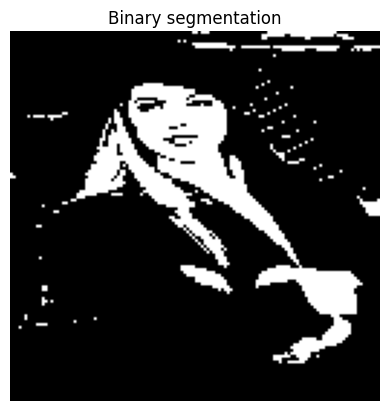

In [12]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_,th = cv2.threshold(gray,120,255,cv2.THRESH_BINARY)

plt.imshow(th, cmap='gray')
plt.title('Binary segmentation')
plt.axis('off')

## 4. Detección de bordes

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

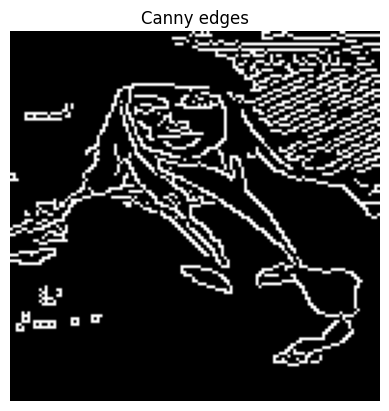

In [13]:
edges = cv2.Canny(gray,100,200)
plt.imshow(edges, cmap='gray')
plt.title('Canny edges')
plt.axis('off')

## 5. Extracciòn de bordes

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

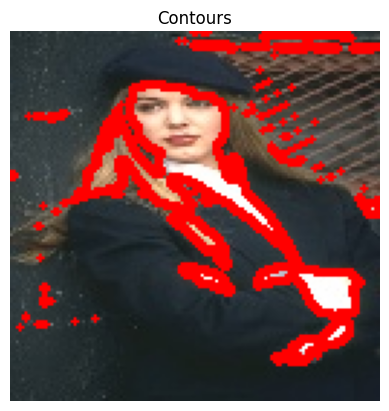

In [14]:
contours,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_cont = img.copy()
cv2.drawContours(img_cont, contours, -1, (255,0,0),2)

plt.imshow(img_cont)
plt.title('Contours')
plt.axis('off')

## 6. Métricas de la imagen

In [15]:
for c in contours:
 area = cv2.contourArea(c)
 perimeter = cv2.arcLength(c,True)
 print('Area:', area, ' Perimeter:', perimeter)

Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 6.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 2.0
Area: 0.0  Perimeter: 0.0
Area: 1.0  Perimeter: 4.828427076339722
Area: 1.0  Perimeter: 4.0
Area: 58.5  Perimeter: 44.041630148887634
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 2.0
Area: 0.0  Perimeter: 2.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 2.0
Area: 1.0  Perimeter: 6.828427076339722
Area: 18.5  Perimeter: 23.899494767189026
Area: 0.0  Perimeter: 6.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 2.0
Area: 0.5  Perimeter: 3.414213538169861
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 10.828427076339722
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 2.0  Perimeter: 14.485281229019165
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 0.0
Area: 0.0  Perimeter: 4.0
Area: 0.0  P